In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import tensorflow as tf
from datetime import datetime

from utils.data_loader import create_datasets
from utils.models import build_baseline_cnn

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


In [2]:
model_name = 'RAF'

Load pretrained model to fine-tune it? If yes, specify model name, if no set it to `None`.

In [3]:
pretrained_model_name = None

# Data

## Preprocessing Function
Pixel values per channel are normalized to have zero mean and unit variance.

In [4]:
# RAF-DB training data mean and std
mean = [146.6770, 114.6274, 102.3102]
std = [67.6282, 61.7651, 61.3665]

def preprocess(x):
    x = np.array(x, dtype='float32')
    x[..., 0] -= mean[0]
    x[..., 1] -= mean[1]
    x[..., 2] -= mean[2]
    if std is not None:
        x[..., 0] /= std[0]
        x[..., 1] /= std[1]
        x[..., 2] /= std[2] 
    return x

def de_preprocess(x):
    x = np.array(x, dtype='float32')
    if std is not None:
        x[..., 0] *= std[0]
        x[..., 1] *= std[1]
        x[..., 2] *= std[2]
    x[..., 0] += mean[0]
    x[..., 1] += mean[1]
    x[..., 2] += mean[2]
    return np.clip(x, 0, 255).astype('uint8')

## Load Data

In [5]:
%%time

IMG_SIZE = (100, 100)
IMG_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 16

train_ds, val_ds, test_ds, class_weights, info = create_datasets(
    data_dir='data/DATASET',
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=0.2,
    augment_train=True
)

📦 LOADING DATASETS
  📁 Loaded train: 12,271 ảnh, 7 classes
  📁 Loaded test: 3,068 ảnh, 7 classes

  📊 Split Summary:
     Train:      9,816 ảnh
     Validation: 2,455 ảnh
     Test:       3,068 ảnh
  ⚖️ Class Weights:
     0 (Surprise  ): 1.3588
     1 (Fear      ): 6.2324
     2 (Disgust   ): 2.4430
     3 (Happiness ): 0.3674
     4 (Sadness   ): 0.8847
     5 (Anger     ): 2.4863
     6 (Neutral   ): 0.6945

  ✅ Datasets created successfully!
     Image size: (100, 100)
     Batch size: 16
CPU times: total: 1.38 s
Wall time: 1.4 s


In [6]:
emotion_labels = ['surprise', 'fear', 'disgust', 'happiness', 'sadness', 'anger', 'neutral']
num_classes = len(emotion_labels)
print('Number of classes: ', num_classes)

Number of classes:  7


## Data Examples

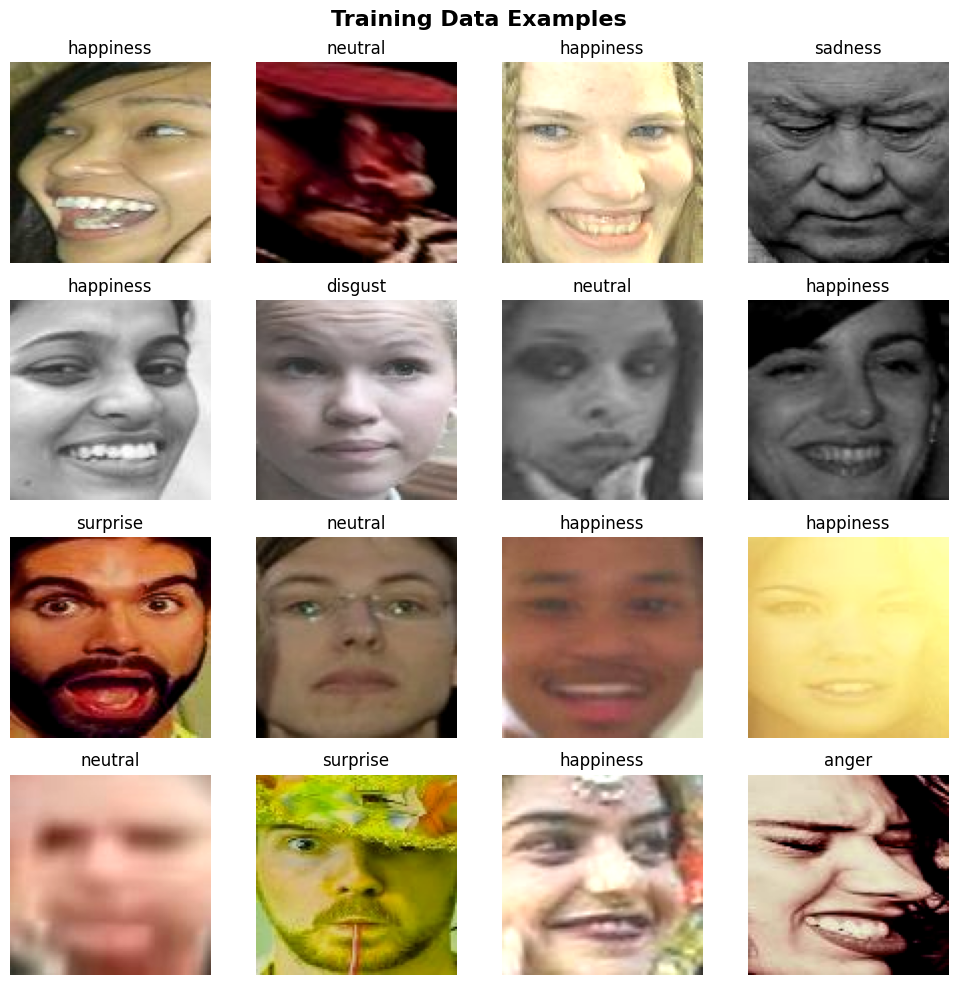

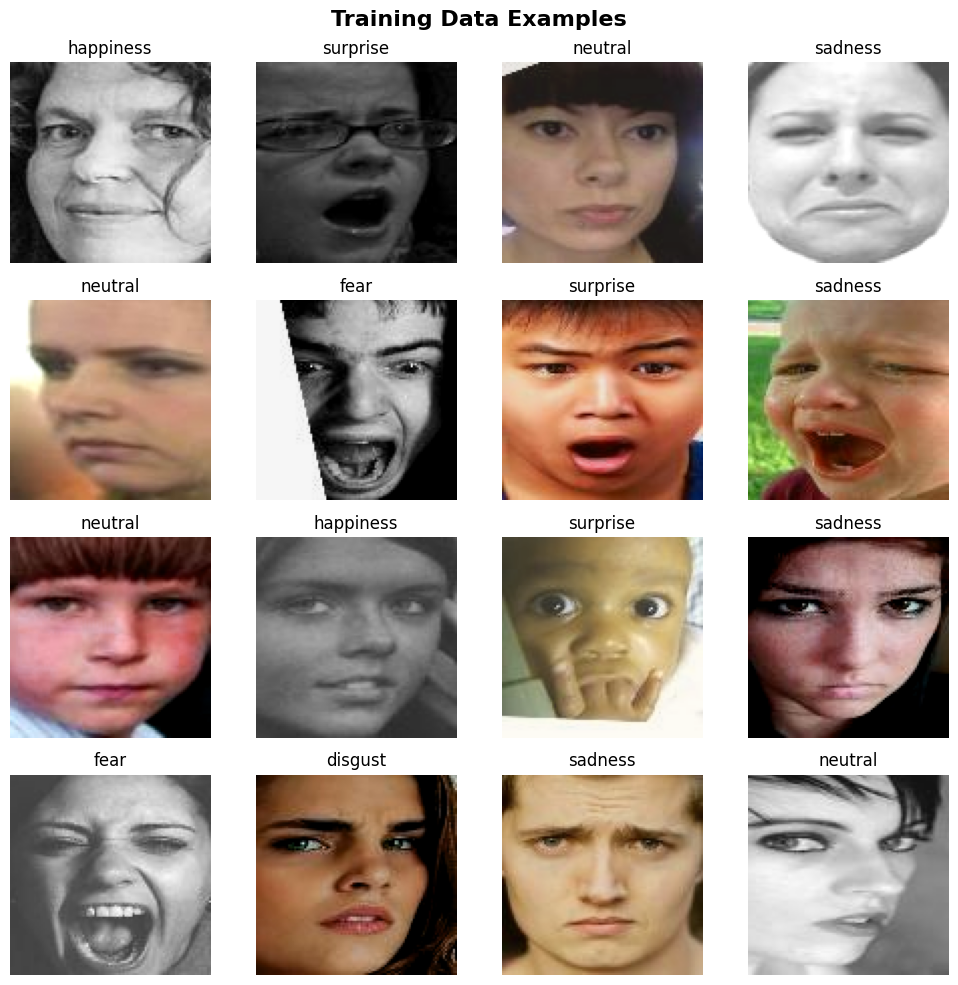

In [8]:
%matplotlib inline
images, labels = next(iter(train_ds))
images_np = images.numpy()
labels_np = labels.numpy()

plt.subplots(4, 4, figsize=(10, 10))
for i in range(min(16, len(images_np))):
    plt.subplot(4, 4, i+1)
    plt.imshow(de_preprocess(images_np[i]))
    plt.title(emotion_labels[int(labels_np[i])])
    plt.axis('off')
plt.suptitle('Training Data Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Model

## Build Model
Model đã bao gồm softmax layer — KHÔNG cần thêm Dense layer.

In [18]:
model = build_baseline_cnn(input_shape=IMG_SHAPE, num_classes=num_classes, dropout_rate=0.25)

if pretrained_model_name is not None:
    model.load_weights(f'./models/{pretrained_model_name}')

# sparse_categorical_crossentropy vi labels la integer (0-6)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (ConvLayer)        │ (None, 100, 100, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (ConvLayer)        │ (None, 100, 100, 64)   │        37,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 33, 33, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (ConvLayer)        │ (None, 33, 33, 96)     │        55,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (ConvLayer)        │ (None, 33, 33, 96)     │        83,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv3 (ConvLayer)        │ (None, 33, 33, 96)     │        83,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 11, 11, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (ConvLayer)        │ (None, 11, 11, 128)    │       111,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (ConvLayer)        │ (None, 11, 11, 128)    │       148,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (ConvLayer)        │ (None, 11, 11, 128)    │       148,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 670,183 (2.56 MB)

 Trainable params: 668,583 (2.55 MB)

 Non-trainable params: 1,600 (6.25 KB)

In [10]:
%matplotlib inline
model = build_baseline_cnn(input_shape=IMG_SHAPE, num_classes=num_classes, dropout_rate=0.25)
model.load_weights('./modelcheckpoints/RAF_0503-2306.keras')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (ConvLayer)        │ (None, 100, 100, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (ConvLayer)        │ (None, 100, 100, 64)   │        37,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 33, 33, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (ConvLayer)        │ (None, 33, 33, 96)     │        55,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (ConvLayer)        │ (None, 33, 33, 96)     │        83,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv3 (ConvLayer)        │ (None, 33, 33, 96)     │        83,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 11, 11, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (ConvLayer)        │ (None, 11, 11, 128)    │       111,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (ConvLayer)        │ (None, 11, 11, 128)    │       148,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (ConvLayer)        │ (None, 11, 11, 128)    │       148,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 670,183 (2.56 MB)

 Trainable params: 668,583 (2.55 MB)

 Non-trainable params: 1,600 (6.25 KB)

# Training

In [9]:
dt = datetime.now().strftime('%m%d-%H%M')
os.makedirs('./modelcheckpoints', exist_ok=True)
os.makedirs('./log', exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f'./modelcheckpoints/{model_name}_{dt}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=4,
        verbose=1,
        mode='auto',
        min_lr=1e-8
    ),
    tf.keras.callbacks.CSVLogger(
        f'./log/{model_name}_{dt}.csv',
        separator=',', append=True
    )
]

In [10]:
%%time

epochs = 20

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.1848 - loss: 2.0210
Epoch 1: val_accuracy improved from None to 0.28391, saving model to ./modelcheckpoints/RAF_0503-2306.keras

Epoch 1: finished saving model to ./modelcheckpoints/RAF_0503-2306.keras
614/614 ━━━━━━━━━━━━━━━━━━━━ 281s 451ms/step - accuracy: 0.1957 - loss: 1.9649 - val_accuracy: 0.2839 - val_loss: 1.8801 - learning_rate: 0.0010
Epoch 2/20
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.2161 - loss: 1.9036
Epoch 2: val_accuracy improved from 0.28391 to 0.36130, saving model to ./modelcheckpoints/RAF_0503-2306.keras

Epoch 2: finished saving model to ./modelcheckpoints/RAF_0503-2306.keras
614/614 ━━━━━━━━━━━━━━━━━━━━ 275s 447ms/step - accuracy: 0.2282 - loss: 1.8834 - val_accuracy: 0.3613 - val_loss: 1.6982 - learning_rate: 0.0010
Epoch 3/20
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2758 - loss: 1.7988
Epoch 3: val_accuracy did not improve from 0.36130
614/614 ━━━━━━━━━━━━━━━━━━━━

# Results

## Training Curves

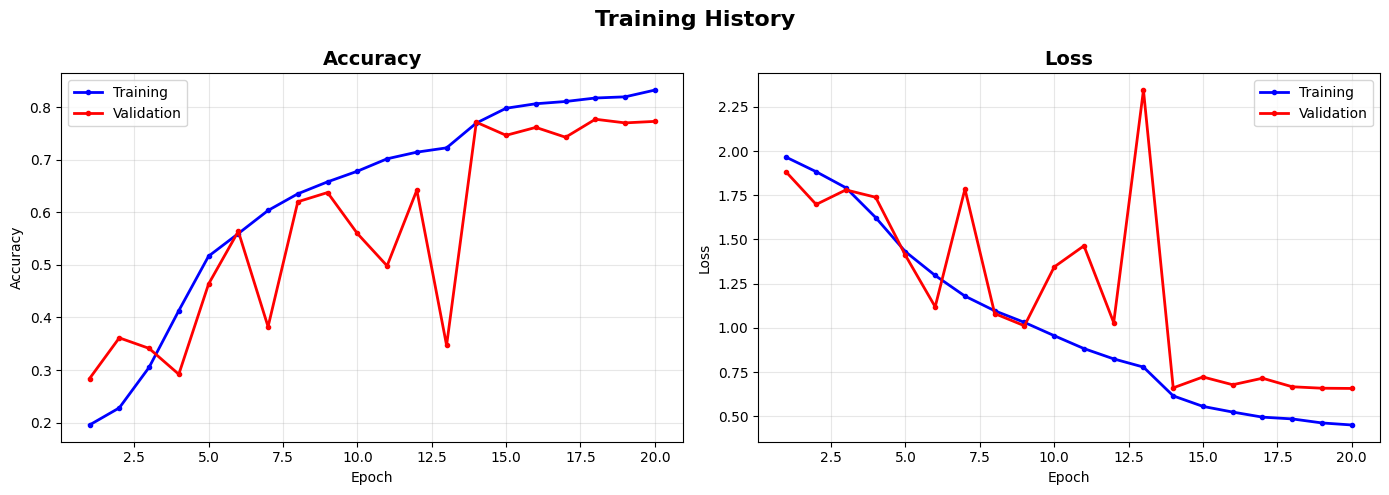

Best Val Accuracy: 0.7768


In [5]:
%matplotlib inline

if 'history' in locals():
    history_dict = history.history
else:
    log_files = glob.glob('log/RAF_*.csv')
    if log_files:
        latest_log = max(log_files, key=os.path.getmtime)
        history_dict = pd.read_csv(latest_log).to_dict(orient='list')
    else:
        history_dict = None
        print('No history found.')

if history_dict:
    plt.figure(figsize=(14, 5))
    ep = range(1, len(history_dict['accuracy']) + 1)

    plt.subplot(1,2,1)
    plt.plot(ep, history_dict['accuracy'], 'b-o', ms=3, lw=2, label='Training')
    plt.plot(ep, history_dict['val_accuracy'], 'r-o', ms=3, lw=2, label='Validation')
    plt.title('Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(ep, history_dict['loss'], 'b-o', ms=3, lw=2, label='Training')
    plt.plot(ep, history_dict['val_loss'], 'r-o', ms=3, lw=2, label='Validation')
    plt.title('Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True, alpha=0.3); plt.legend()

    plt.suptitle('Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Best Val Accuracy: {max(history_dict["val_accuracy"]):.4f}')


## Test Results

In [11]:
loss, acc = model.evaluate(test_ds, verbose=2)
print(f'\nAccuracy:\t{acc * 100:.2f}%')
print(f'Loss:\t\t{loss:.4f}')

192/192 - 18s - 92ms/step - accuracy: 0.7689 - loss: 0.6674

Accuracy:	76.89%
Loss:		0.6674


In [12]:
model = tf.keras.models.load_model('outputs/models/baseline_cnn.keras')
model.summary()

TypeError: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 2152768122320}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 100, 100, 3], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer', 'optional': False}, 'registered_name': None}, {'module': 'utils.models', 'class_name': 'ConvLayer', 'config': {'name': 'block1_conv1', 'kernel_num': 64, 'kernel_size': [3, 3], 'strides': 1, 'padding': 'same', 'kernel_initializer': 'he_normal', 'trainable': True, 'dtype': {'mo

## Confusion Matrix & Classification Report

Classification Report:
              precision    recall  f1-score   support

    surprise     0.7280    0.8298    0.7756       329
        fear     0.4138    0.4865    0.4472        74
     disgust     0.4647    0.4938    0.4788       160
   happiness     0.9499    0.8321    0.8871      1185
     sadness     0.7076    0.6987    0.7032       478
       anger     0.6010    0.7346    0.6611       162
     neutral     0.7308    0.7824    0.7557       680

    accuracy                         0.7689      3068
   macro avg     0.6565    0.6940    0.6727      3068
weighted avg     0.7831    0.7689    0.7735      3068



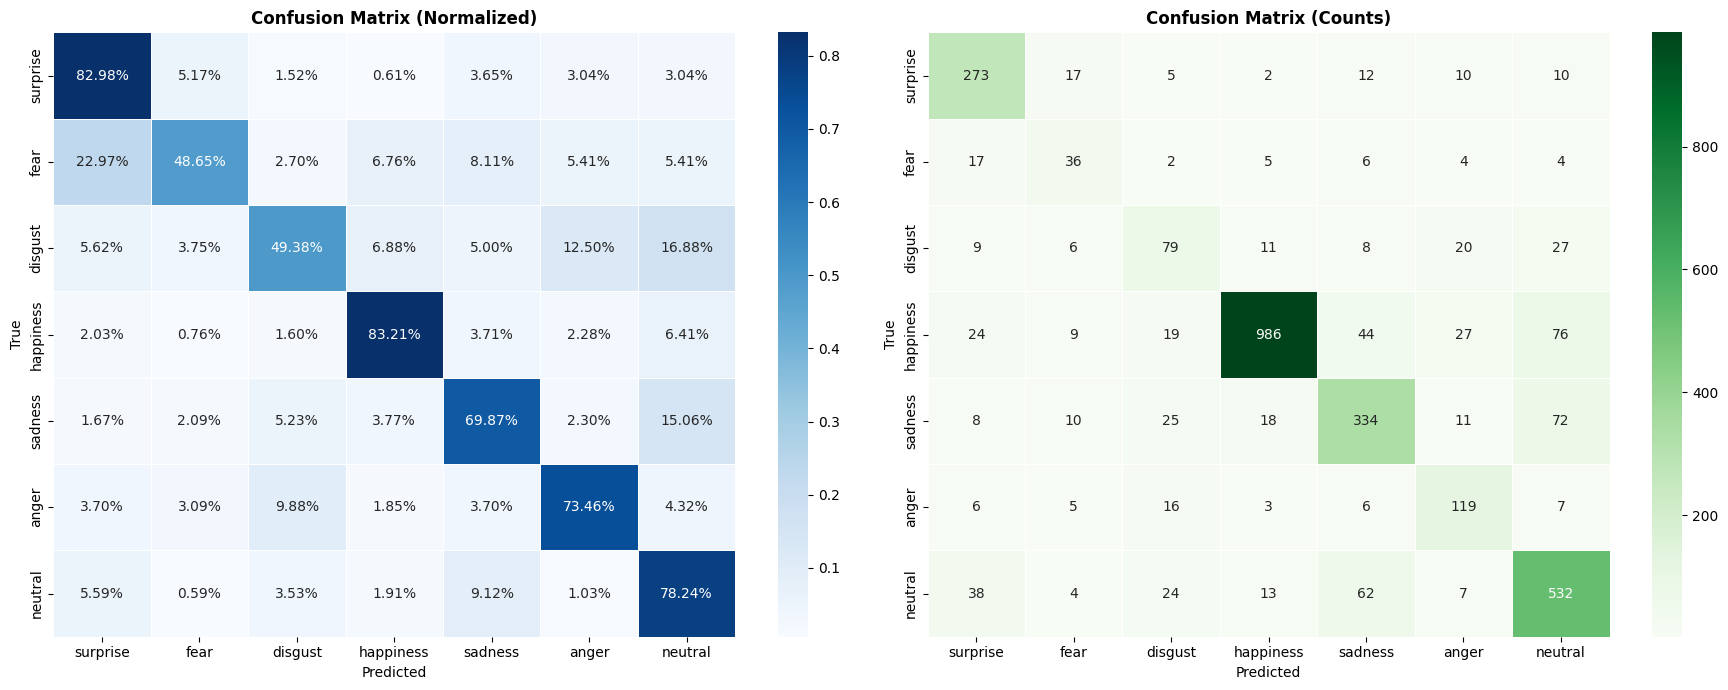

In [13]:
%matplotlib inline
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print('Classification Report:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=emotion_labels, digits=4))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=emotion_labels, yticklabels=emotion_labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Per-class Accuracy

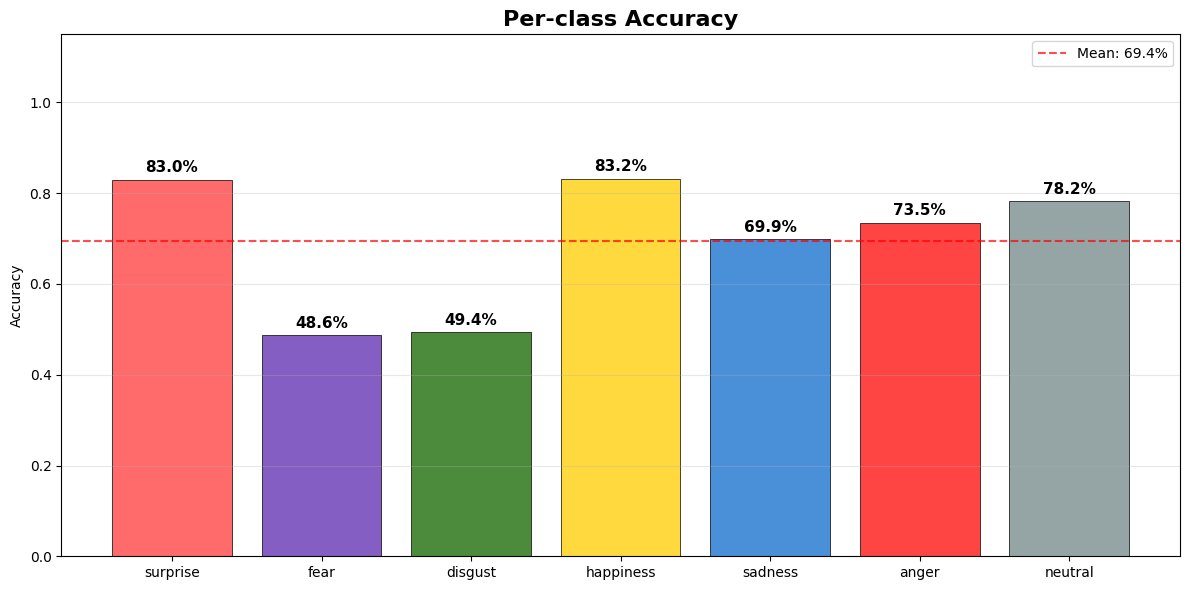

In [14]:
%matplotlib inline
per_class_acc = cm_norm.diagonal()
colors = ['#FF6B6B','#845EC2','#4B8B3B','#FFD93D','#4A90D9','#FF4444','#95A5A6']
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(emotion_labels, per_class_acc, color=colors, edgecolor='black', lw=0.5)
for bar, v in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(y=np.mean(per_class_acc), color='red', ls='--', alpha=0.7,
           label=f'Mean: {np.mean(per_class_acc):.1%}')
ax.set_ylabel('Accuracy'); ax.set_title('Per-class Accuracy', fontsize=16, fontweight='bold')
ax.set_ylim(0,1.15); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Save Model

In [15]:
os.makedirs('outputs/models', exist_ok=True)
model.save('outputs/models/baseline_cnn.keras')
print('Da luu model thanh cong!')
print('Path: outputs/models/baseline_cnn.keras')
print('Chay Webcam demo: python app/run.py')

Da luu model thanh cong!
Path: outputs/models/baseline_cnn.keras
Chay Webcam demo: python app/run.py


---